# Random Forest Classifier
Random Forest is an ensemble learning method that combines multiple decision trees to improve accuracy and reduce overfitting. It can be used for both classification and regression tasks.

# Benefits of Random Forest Classification:
Handles large datasets and high-dimensional data efficiently.

Reduces overfitting by averaging multiple trees' predictions.

Works well with noisy and categorical data.

# Working of Random Forest Classifier

Bootstrap Sampling – Random Forest Classification works by creating multiple decision trees each trained on a random subset of data. The process begins with Bootstrap Sampling where random rows of data are selected with replacement to form different training datasets for each tree.

Feature Sampling – Then where only a random subset of features is used to build each tree ensuring diversity across the models.

Decision Tree Construction – Each tree splits data based on criteria like Gini impurity or information gain.

Prediction Aggregation – In classification, the final output is determined by majority voting.

# Implementing Random Forest Classification in Python

## parameters:
n_estimators: Number of trees in the forest.

max_depth: Maximum depth of each tree.

max_features: Number of features considered for splitting at each node.

criterion: Function used to measure split quality (‘gini’ or ‘entropy’).

min_samples_split: Minimum samples required to split a node.

min_samples_leaf: Minimum samples required to be at a leaf node.

bootstrap: Whether to use bootstrap sampling when building trees (True or False).

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Suppress warnings
warnings.filterwarnings("ignore")


# Load dataset
df = sns.load_dataset("titanic")  # Update with correct path if needed


In [ ]:
# Fill missing values
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)

df['Cabin_Category'] = df['deck'].str[0]
df.drop(['deck'], axis=1, inplace=True)
df['Cabin_Category'].fillna('U', inplace=True) # u - unknown

# Family size
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

# Bin Age and Fare
df['AgeBin'] = pd.cut(df['age'], bins=[0, 12, 20, 40, 60, 100], labels=[0, 1, 2, 3, 4])
df['FareBin'] = pd.qcut(df['fare'], 4, labels=[0, 1, 2, 3])
df.drop(['age', 'fare'], axis=1, inplace=True)

# Encode categorical variables
encoder = LabelEncoder()
for col in ['sex', 'embarked','Cabin_Category','AgeBin', 'FareBin','alive','alone','class','who','adult_male']:
    df[col] = encoder.fit_transform(df[col])

df['embark_town'] = df['embark_town'].map({'Southampton': 0, 'Cherbourg': 1, 'Queenstown': 2})    


print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   survived        891 non-null    int64  
 1   pclass          891 non-null    int64  
 2   sex             891 non-null    int32  
 3   sibsp           891 non-null    int64  
 4   parch           891 non-null    int64  
 5   embarked        891 non-null    int32  
 6   class           891 non-null    int32  
 7   who             891 non-null    int32  
 8   adult_male      891 non-null    int64  
 9   embark_town     889 non-null    float64
 10  alive           891 non-null    int32  
 11  alone           891 non-null    int64  
 12  Cabin_Category  891 non-null    int32  
 13  FamilySize      891 non-null    int64  
 14  AgeBin          891 non-null    int64  
 15  FareBin         891 non-null    int64  
dtypes: float64(1), int32(6), int64(9)
memory usage: 90.6 KB
None


In [52]:
df.head(5)

,survived,pclass,sex,sibsp,parch,embarked,class,who,adult_male,embark_town,alive,alone,Cabin_Category,FamilySize,AgeBin,FareBin
0,0,3,1,1,0,2,2,1,1,0.0,0,0,7,2,2,0
1,1,1,0,1,0,0,0,2,0,1.0,1,0,2,2,2,3
2,1,3,0,0,0,2,2,2,0,0.0,1,1,7,1,2,1
3,1,1,0,1,0,2,0,2,0,0.0,1,0,2,2,2,3
4,0,3,1,0,0,2,2,1,1,0.0,0,1,7,1,2,1


In [49]:
# Split data
X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_
print(best_rf)
print(grid_search.best_params_)
y_pred = best_rf.predict(X_test)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
RandomForestClassifier(max_depth=5, random_state=42)
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



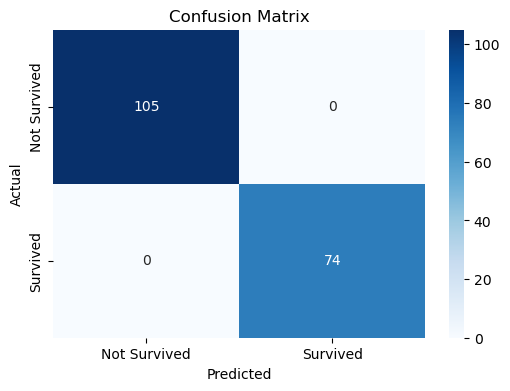

In [54]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Example 2: 
we’ll use the Iris Dataset which is available within sklearn. This dataset contains information about three types of Iris flowers and their respective features (sepal length, sepal width, petal length and petal width).

In [63]:
from sklearn.datasets import load_iris

In [64]:
# load data
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [65]:
# Data Preparation
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values


In [66]:
# Splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Feature Scaling
Feature scaling ensures that all the features are on a similar scale which is important for some machine learning models. However Random Forest is not highly sensitive to feature scaling. But it is a good practice to scale when combining models.

In [67]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


 # Building Random Forest Classifier
 create the Random Forest Classifier model, train it on the training data and make predictions on the test data.

In [68]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)


# Evaluation of the Model
We will evaluate the model using the accuracy score and confusion matrix.

Accuracy: 100.00%


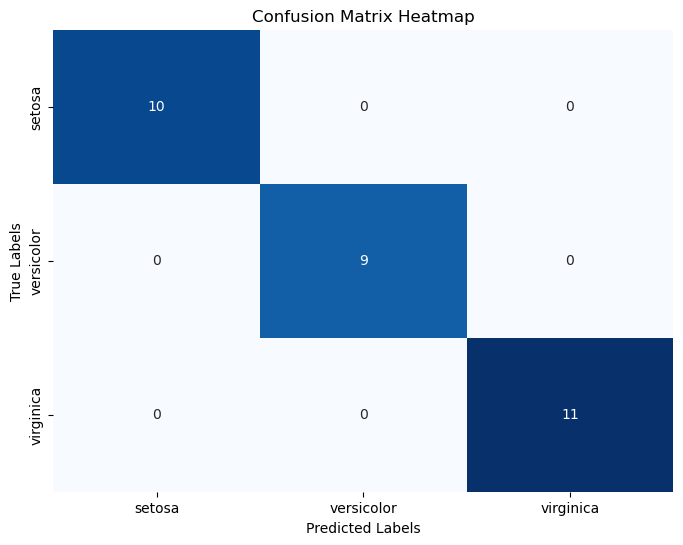

In [69]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=iris.target_names, yticklabels=iris.target_names)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


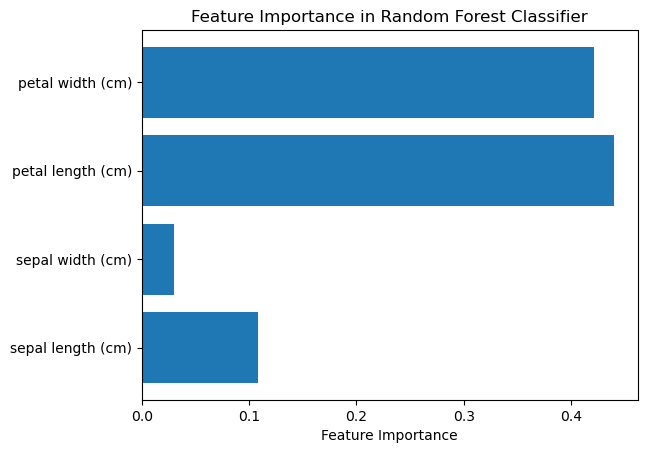

In [70]:
# Feature Importance
feature_importances = classifier.feature_importances_

plt.barh(iris.feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()


From the graph we can see that petal width (cm) is the most important feature followed closely by petal length (cm). The sepal width (cm) and sepal length (cm) have lower importance in determining the model’s predictions. This indicates that the classifier relies more on the petal measurements to make predictions about the flower species.

Random Forest Classifiers are useful for classification tasks offering high accuracy and robustness. They are easy to use, provide insights into feature importance and can handle complex datasets.